# Sales Forecasting - Gargi Nemade

Introduction

Sales forecasting is an important part of business planning because it helps organizations estimate future demand, manage inventory, allocate resources, and make informed business decisions. Accurate sales forecasts can reduce stock shortages, prevent overstocking, and improve overall operational efficiency.

In this project, the Superstore Sales dataset is used to analyze historical sales data and build predictive models for future sales. The project begins with data preprocessing and exploratory data analysis (EDA) to understand sales trends, seasonal patterns, and customer purchasing behavior.

Three forecasting approaches: SARIMA, Facebook Prophet, and XGBoost are implemented and compared using performance metrics such as MAE, RMSE, and MAPE to identify the most accurate forecasting model. In addition to forecasting, the project includes anomaly detection to identify unusual sales patterns and K-Means clustering to segment products based on their demand characteristics.

Finally, the insights are presented through an interactive Streamlit dashboard, allowing users to explore sales trends, forecasts, anomalies, and product demand segments in an easy-to-use interface. The overall objective is to demonstrate how data analysis and machine learning techniques can support better business planning and decision-making.

# Task 1 — Data Loading, Merging & Deep Exploration

In [13]:
# import necessary libraries 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [14]:
# load dataset
df = pd.read_csv("train.csv")
df.head(10)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680
5,6,CA-2015-115812,09/06/2015,14/06/2015,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032.0,West,FUR-FU-10001487,Furniture,Furnishings,Eldon Expressions Wood and Plastic Desk Access...,48.8600
6,7,CA-2015-115812,09/06/2015,14/06/2015,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032.0,West,OFF-AR-10002833,Office Supplies,Art,Newell 322,7.2800
7,8,CA-2015-115812,09/06/2015,14/06/2015,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032.0,West,TEC-PH-10002275,Technology,Phones,Mitel 5320 IP Phone VoIP phone,907.1520
8,9,CA-2015-115812,09/06/2015,14/06/2015,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032.0,West,OFF-BI-10003910,Office Supplies,Binders,DXL Angle-View Binders with Locking Rings by S...,18.5040
9,10,CA-2015-115812,09/06/2015,14/06/2015,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032.0,West,OFF-AP-10002892,Office Supplies,Appliances,Belkin F5C206VTEL 6 Outlet Surge,114.9000


In [15]:
df.shape

(9800, 18)

In [16]:
# Convert columns to datetime
df["Order Date"] = pd.to_datetime(df["Order Date"], format="%d/%m/%Y")
df["Ship Date"] = pd.to_datetime(df["Ship Date"], format="%d/%m/%Y")

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9800 non-null   int64         
 1   Order ID       9800 non-null   object        
 2   Order Date     9800 non-null   datetime64[ns]
 3   Ship Date      9800 non-null   datetime64[ns]
 4   Ship Mode      9800 non-null   object        
 5   Customer ID    9800 non-null   object        
 6   Customer Name  9800 non-null   object        
 7   Segment        9800 non-null   object        
 8   Country        9800 non-null   object        
 9   City           9800 non-null   object        
 10  State          9800 non-null   object        
 11  Postal Code    9789 non-null   float64       
 12  Region         9800 non-null   object        
 13  Product ID     9800 non-null   object        
 14  Category       9800 non-null   object        
 15  Sub-Category   9800 n

In [18]:
# missing values
df.isnull().sum()

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64

In [19]:
state_counts = df["State"].value_counts()
print(state_counts)

State
California              1946
New York                1097
Texas                    973
Pennsylvania             582
Washington               504
Illinois                 483
Ohio                     454
Florida                  373
Michigan                 253
North Carolina           247
Virginia                 224
Arizona                  223
Tennessee                183
Colorado                 179
Georgia                  177
Kentucky                 137
Indiana                  135
Massachusetts            135
Oregon                   122
New Jersey               122
Maryland                 105
Wisconsin                105
Delaware                  93
Minnesota                 89
Connecticut               82
Missouri                  66
Oklahoma                  66
Alabama                   61
Arkansas                  60
Rhode Island              55
Mississippi               53
Utah                      53
South Carolina            42
Louisiana                 41
Nevada  

In [20]:
#For every row where the Postal Code is missing, look for another row with the same City and State and fill it with it.
df["Postal Code"] = df["Postal Code"].fillna(
    df.groupby(["City", "State"])["Postal Code"].transform("first")
)

In [21]:
df["Postal Code"].isnull().sum()

np.int64(11)

Postal Code had 11 missing values. Missing values were filled where another record with the same City and State contained a valid postal code. The remaining 11 values had no corresponding postal code elsewhere in the dataset, so they were retained as NaN to avoid introducing incorrect information.

In [22]:
# duplicate rows
df.duplicated().sum()

np.int64(0)

In [23]:
# Time Features
df["Year"] = df["Order Date"].dt.year
df["Month"] = df["Order Date"].dt.month
df["Month Name"] = df["Order Date"].dt.month_name()
df["Week"] = df["Order Date"].dt.isocalendar().week
df["Quarter"] = df["Order Date"].dt.quarter
df["Day"] = df["Order Date"].dt.day_name()

In [24]:
# season
def season(month):
    if month in [12,1,2]:
        return "Winter"
    elif month in [3,4,5]:
        return "Summer"
    elif month in [6,7,8,9]:
        return "Monsoon"
    else:
        return "Autumn"

df["Season"] = df["Month"].apply(season)

In [25]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Sub-Category,Product Name,Sales,Year,Month,Month Name,Week,Quarter,Day,Season
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Bookcases,Bush Somerset Collection Bookcase,261.9600,2017,11,November,45,4,Wednesday,Autumn
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,2017,11,November,45,4,Wednesday,Autumn
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2017,6,June,24,2,Monday,Monsoon
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,2016,10,October,41,4,Tuesday,Autumn
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Storage,Eldon Fold 'N Roll Cart System,22.3680,2016,10,October,41,4,Tuesday,Autumn


In [26]:
df.describe(include="all")

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Sub-Category,Product Name,Sales,Year,Month,Month Name,Week,Quarter,Day,Season
count,9800.000000,9800,9800,9800,9800,9800,9800,9800,9800,9800,...,9800,9800,9800.000000,9800.000000,9800.000000,9800,9800.0,9800.000000,9800,9800
unique,NaN,4922,NaN,NaN,4,793,793,3,1,529,...,17,1849,NaN,NaN,NaN,12,<NA>,NaN,7,4
top,NaN,CA-2018-100111,NaN,NaN,Standard Class,WB-21850,William Brown,Consumer,United States,New York City,...,Binders,Staple envelope,NaN,NaN,NaN,November,<NA>,NaN,Tuesday,Monsoon
freq,NaN,14,NaN,NaN,5859,35,35,5101,9800,891,...,1492,47,NaN,NaN,NaN,1449,<NA>,NaN,1889,3435
mean,4900.500000,NaN,2017-05-01 05:13:51.673469440,2017-05-05 04:17:52.653061120,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,230.769059,2016.724184,7.818469,NaN,32.210102,2.885816,NaN,NaN
min,1.000000,NaN,2015-01-03 00:00:00,2015-01-07 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,0.444000,2015.000000,1.000000,NaN,1.0,1.000000,NaN,NaN
25%,2450.750000,NaN,2016-05-24 00:00:00,2016-05-27 18:00:00,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,17.248000,2016.000000,5.000000,NaN,21.0,2.000000,NaN,NaN
50%,4900.500000,NaN,2017-06-26 00:00:00,2017-06-29 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,54.490000,2017.000000,9.000000,NaN,35.0,3.000000,NaN,NaN
75%,7350.250000,NaN,2018-05-15 00:00:00,2018-05-19 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,210.605000,2018.000000,11.000000,NaN,45.0,4.000000,NaN,NaN
max,9800.000000,NaN,2018-12-30 00:00:00,2019-01-05 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,22638.480000,2018.000000,12.000000,NaN,53.0,4.000000,NaN,NaN


In [27]:
# Weekly Sales
weekly_sales = (
    df.resample("W", on="Order Date")["Sales"]
      .sum()
)
weekly_sales.head()

Order Date
2015-01-04     304.508
2015-01-11    4619.108
2015-01-18    4130.533
2015-01-25    3092.544
2015-02-01    2527.914
Freq: W-SUN, Name: Sales, dtype: float64

In [28]:
# Monthly Sales
monthly_sales = (
    df.resample("M", on="Order Date")["Sales"]
      .sum()
)
monthly_sales.head()

/var/folders/g4/jhh2v6r92n33y0vh8zvgs3w80000gn/T/ipykernel_22389/1537274841.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df.resample("M", on="Order Date")["Sales"]


Order Date
2015-01-31    14205.707
2015-02-28     4519.892
2015-03-31    55205.797
2015-04-30    27906.855
2015-05-31    23644.303
Freq: ME, Name: Sales, dtype: float64

not using groupby as this combines January 2014, January 2015, January 2016, and January 2017, so it's not suitable for forecasting.

In [29]:
# Which product category generates the highest total revenue?
category_sales = (
    df.groupby("Category")["Sales"]
      .sum()
      .sort_values(ascending=False)
)

print(category_sales)

Category
Technology         827455.8730
Furniture          728658.5757
Office Supplies    705422.3340
Name: Sales, dtype: float64


The Technology category has the highest total revenue of 827455.8730.

In [30]:
# Which region has the most consistent sales growth over 4 years?
region_year_sales = (
    df.groupby(["Year","Region"])["Sales"]
      .sum()
      .reset_index()
)
region_year_sales.head()

,Year,Region,Sales
0,2015,Central,102920.5206
1,2015,East,127652.8190
2,2015,South,103374.9055
3,2015,West,145907.9630
4,2016,Central,102425.1724


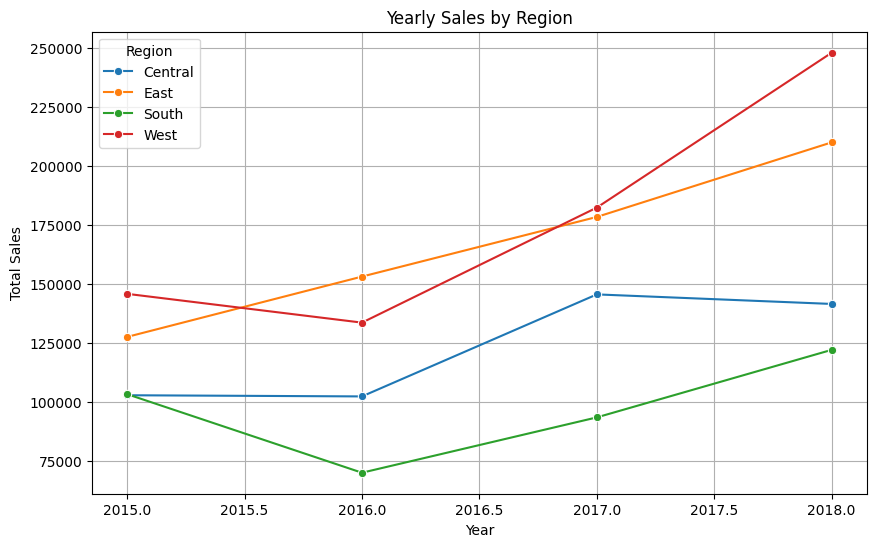

In [31]:
plt.figure(figsize=(10,6))
sns.lineplot(
    data=region_year_sales,
    x="Year",
    y="Sales",
    hue="Region",
    marker="o"
)
plt.title("Yearly Sales by Region")
plt.xlabel("Year")
plt.ylabel("Total Sales")
plt.grid(True)
plt.savefig("charts/yearly_region_sales.png")
plt.show()

The East region showed the most consistent sales growth over the four-year period. Sales increased steadily every year without any significant decline, indicating stable and sustained growth. Although the West region achieved the highest total sales by the end of the period, it experienced a decline between 2015 and 2016 before recovering strongly.

In [32]:
# Shipping Time
df["Shipping Days"] = (df["Ship Date"] - df["Order Date"]).dt.days

In [33]:
# What is the average time between Order Date and Ship Date — and does it vary by region?
shipping_time = (
    df.groupby("Region", as_index=False)["Shipping Days"]
      .mean()
)

shipping_time

,Region,Shipping Days
0,Central,4.065876
1,East,3.910233
2,South,3.961202
3,West,3.930255


The average shipping time is approximately 4 days across all regions. The differences between regions are very small, indicating that shipping performance is fairly consistent throughout the country.

In [34]:
# Are there months that consistently spike across all years (seasonality)?
seasonality = (
    df.groupby(["Year","Month"])["Sales"]
      .sum()
      .reset_index()
)
seasonality.head()

,Year,Month,Sales
0,2015,1,14205.707
1,2015,2,4519.892
2,2015,3,55205.797
3,2015,4,27906.855
4,2015,5,23644.303


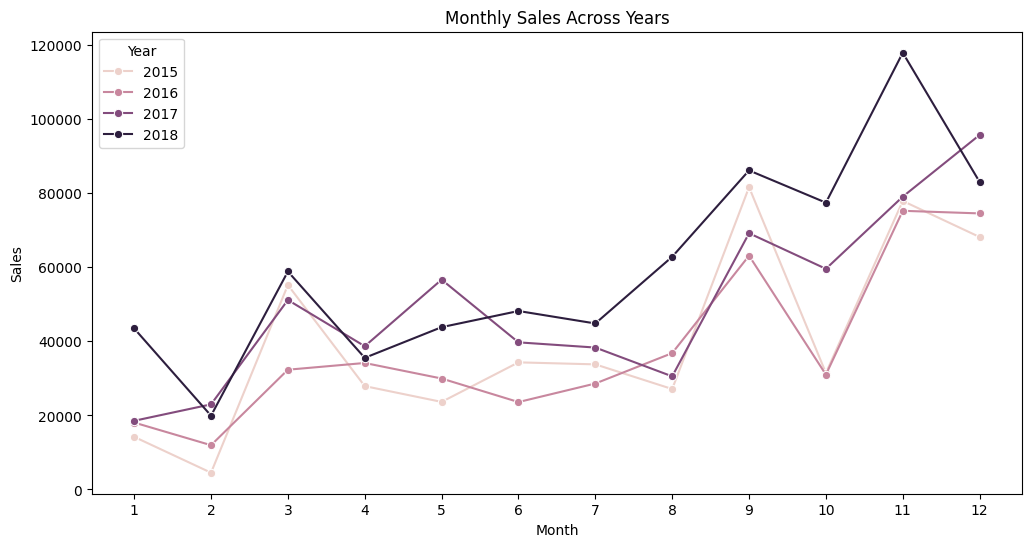

In [35]:
plt.figure(figsize=(12,6))
sns.lineplot(
    data=seasonality,
    x="Month",
    y="Sales",
    hue="Year",
    marker="o"
)
plt.xticks(range(1,13))
plt.title("Monthly Sales Across Years")
plt.savefig("charts/monthly_seasonality.png")
plt.show()

Sales consistently peaked during November and December, indicating strong seasonal demand.

# Task 2 — Time Series Analysis & Decomposition


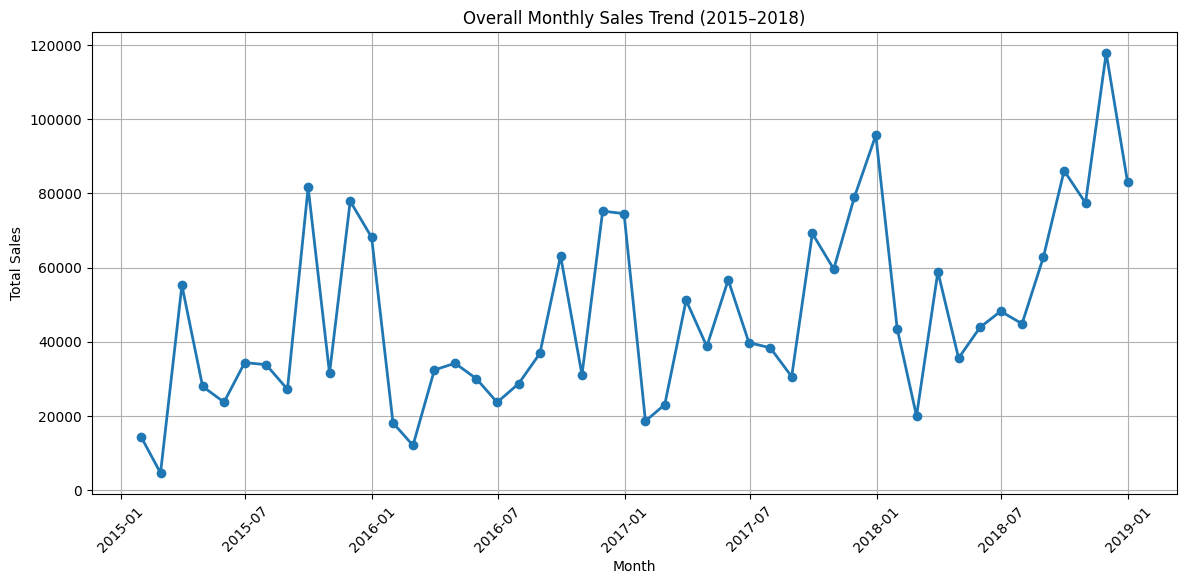

In [36]:
# overall monthly sales trend across all 4 years
plt.figure(figsize=(14,6))

plt.plot(
    monthly_sales.index,
    monthly_sales.values,
    marker="o",
    linewidth=2
)

plt.title("Overall Monthly Sales Trend (2015–2018)")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.grid(True)
plt.savefig("charts/overall_monthly_sales_trend.png")
plt.show()

In [37]:
#Time Series Decomposition
!pip install statsmodels
from statsmodels.tsa.seasonal import seasonal_decompose

In [38]:
decomposition = seasonal_decompose(
    monthly_sales,
    model="additive",  # Observed = Trend + Seasonality + Noise 
    period=12
)

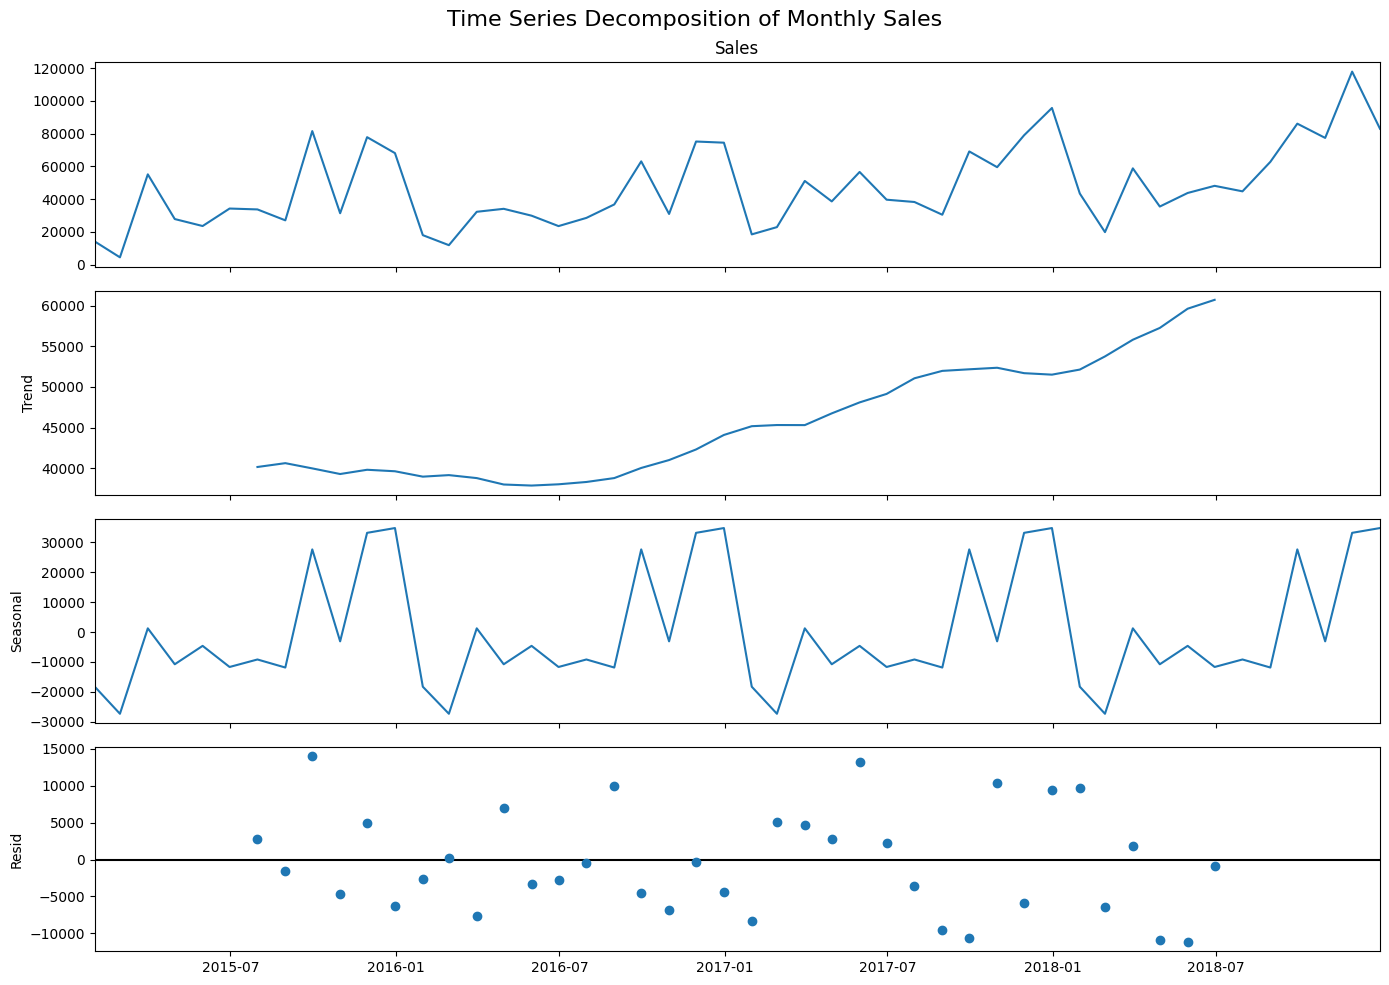

In [39]:
fig = decomposition.plot()
fig.set_size_inches(14, 10)

plt.suptitle("Time Series Decomposition of Monthly Sales", fontsize=16)
plt.tight_layout()

plt.savefig("charts/time_series_decomposition.png", dpi=300)

plt.show()

Observations:
- The trend graph shows that overall sales are increasing over time. Although there are a few small ups and downs, the business is growing steadily across the four years.
- The seasonal graph shows a repeating pattern every year. This means some months regularly have higher sales while others have lower sales, so the data has strong seasonality.
- The residual (noise) graph contains random spikes that are not explained by the trend or seasonal pattern. Most points are close to zero, but a few months have larger positive or negative values.
- The highest residual spikes can be seen around late 2015, mid-2017, and early 2018. These may have been caused by special discounts, festive sales, promotions, or other unexpected events that affected sales.

In [40]:
# Augmented Dickey-Fuller (ADF) Test 
from statsmodels.tsa.stattools import adfuller
adf_result = adfuller(monthly_sales)

print("ADF Statistic :", adf_result[0])
print("p-value :", adf_result[1])
print("Critical Values:")

for key, value in adf_result[4].items():
    print(f"{key}: {value}")

ADF Statistic : -4.416136761430768
p-value : 0.00027791039276670677
Critical Values:
1%: -3.5778480370438146
5%: -2.925338105429433
10%: -2.6007735310095064


What is Stationarity?
A stationary time series is one whose average and variation remain stable over time. It does not have a long-term upward or downward trend. Checking stationarity is important because many forecasting models, such as SARIMA, assume that the data is stationary before making predictions.
The ADF test showed that the monthly sales series is already stationary (p-value = 0.000278 < 0.05). Therefore, differencing was not required. In other words, the data does not have a strong long-term trend that would prevent time series forecasting. 

# Task 3 — Sales Forecasting using 3 Different Models

# Model 1 — SARIMA (Statistical Model)


In [41]:
# SARIMA stands for Seasonal AutoRegressive Integrated Moving Average. It is a statistical time series forecasting model used when the data has both a trend and a seasonal pattern.
!pip install statsmodels

In [80]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
!pip install scikit-learn
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

In [81]:
train = monthly_sales[:-3]
test = monthly_sales[-3:]

print("Training observations:", len(train))
print("Testing observations:", len(test))

Training observations: 45
Testing observations: 3


In [82]:
sarima_model = SARIMAX(
    train,
    order=(1,1,1),
    seasonal_order=(1,1,1,12)
)

sarima_fit = sarima_model.fit()

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


I used SARIMA (1,1,1)(1,1,1,12) because the dataset contains monthly sales data with a yearly seasonal pattern (12 months). First-order differencing (d=1) helps remove the trend, and seasonal differencing (D=1) helps account for yearly seasonality. The values p=1, q=1, P=1, and Q=1 provide a simple starting model suitable for forecasting monthly sales.

In [83]:
# forcast next 3 months 
forecast = sarima_fit.get_forecast(steps=3)

forecast_values = forecast.predicted_mean

confidence_interval = forecast.conf_int()

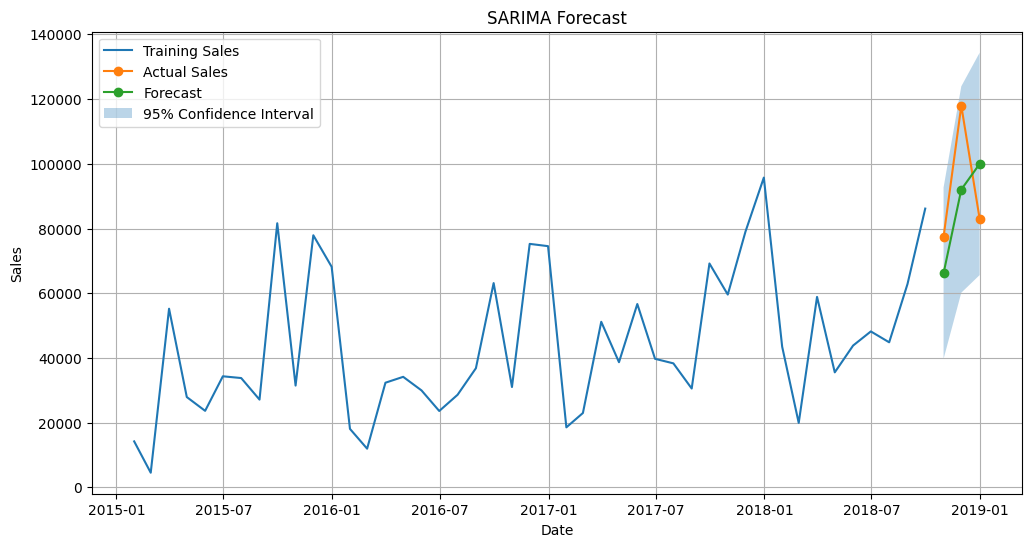

In [84]:
# Plot actual vs forecasted sales
plt.figure(figsize=(12,6))
plt.plot(train.index, train, label="Training Sales")
plt.plot(test.index, test, label="Actual Sales", marker="o")

plt.plot(forecast_values.index,
         forecast_values,
         label="Forecast",
         marker="o")

plt.fill_between(
    confidence_interval.index,
    confidence_interval.iloc[:,0],
    confidence_interval.iloc[:,1],
    alpha=0.3,
    label="95% Confidence Interval"
)

plt.title("SARIMA Forecast")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)
plt.savefig("charts/SARIMA_forecast")
plt.show()

In [85]:
sarima_mae = mean_absolute_error(test, forecast_values)
sarima_rmse = np.sqrt(mean_squared_error(test, forecast_values))
sarima_mape = np.mean(np.abs((test - forecast_values) / test)) * 100

print("MAE:", sarima_mae)
print("RMSE:", sarima_rmse)
print("MAPE:", sarima_mape)

MAE: 18031.404662278193
RMSE: 19009.18206222961
MAPE: 18.966498054122592


# Model 2 — Facebook Prophet (Industry-standard Forecasting Tool)


In [87]:
#Prophet is a time series forecasting model developed by Meta (formerly Facebook). It is designed to predict future values from historical data and works especially well for business data like sales, revenue, website traffic, and demand forecasting.Prophet is a time series forecasting model developed by Meta (formerly Facebook). It is designed to predict future values from historical data and works especially well for business data like sales, revenue, website traffic, and demand forecasting.
!pip install prophet

In [88]:
from prophet import Prophet

In [89]:
#Prepare data in Prophet's required format (ds, y columns)
prophet_df = monthly_sales.reset_index()
prophet_df.columns = ["ds", "y"]
prophet_df.head()

,ds,y
0,2015-01-31,14205.707
1,2015-02-28,4519.892
2,2015-03-31,55205.797
3,2015-04-30,27906.855
4,2015-05-31,23644.303


In [90]:
train = prophet_df[:-3]
test = prophet_df[-3:]

In [91]:
model = Prophet()
model.fit(train)

23:23:04 - cmdstanpy - INFO - Chain [1] start processing
23:23:05 - cmdstanpy - INFO - Chain [1] done processing


In [92]:
future = model.make_future_dataframe(periods=3, freq="M")
prophet_forecast = model.predict(future)

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/prophet/forecaster.py:1875: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(


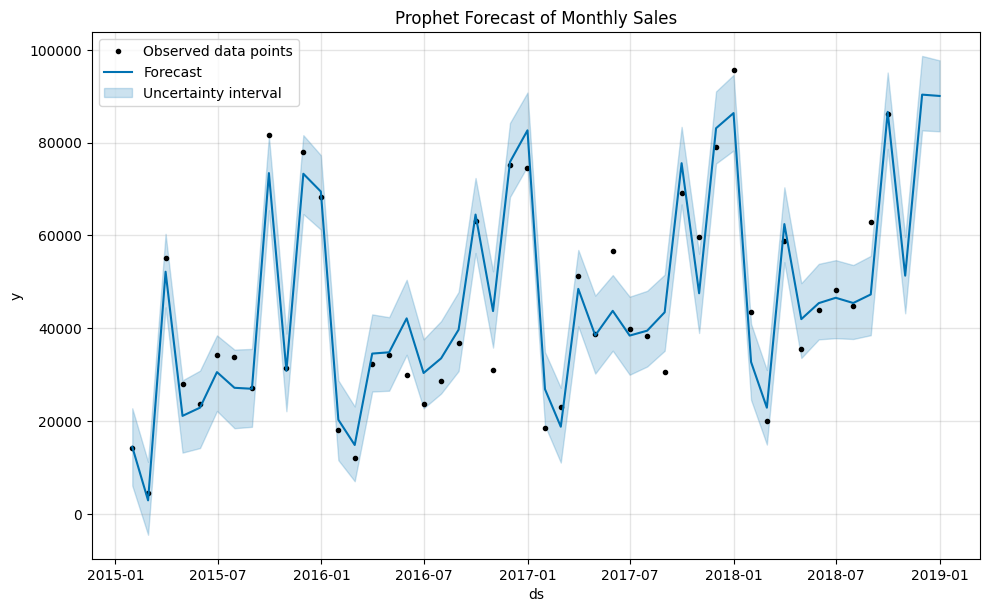

In [93]:
fig1 = model.plot(prophet_forecast)
plt.title("Prophet Forecast of Monthly Sales")
plt.savefig("charts/prohpet_monthly_sales.png")
plt.legend()
plt.show()

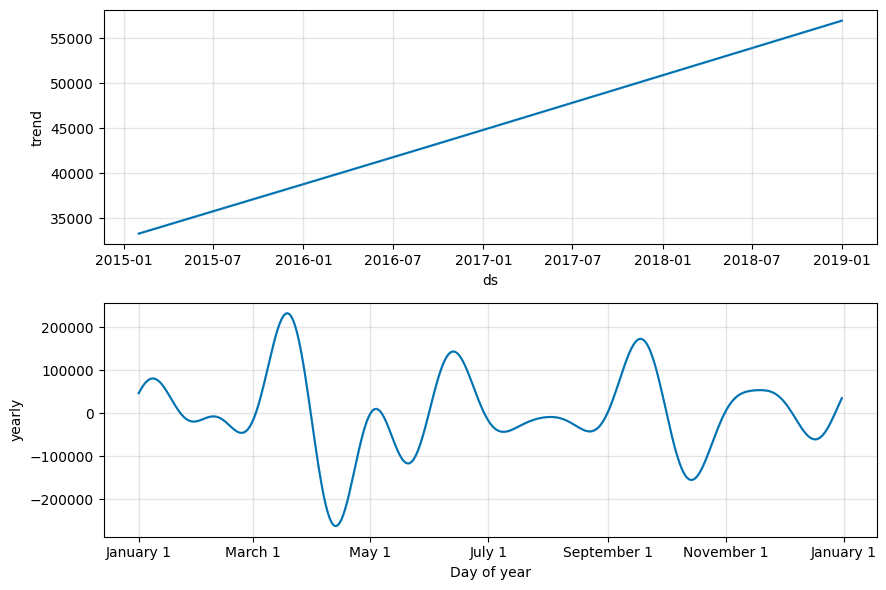

In [94]:
# trend and seasonality
fig2 = model.plot_components(prophet_forecast)
plt.savefig("charts/prohpet_seasonality.png")
plt.show()

In [95]:
prophet_forecast[["ds", "trend", "yearly"]].tail()

,ds,trend,yearly
43,2018-08-31,54942.277263,-7670.719648
44,2018-09-30,55441.607668,31172.344895
45,2018-10-31,55957.582420,-4638.638663
46,2018-11-30,56456.912826,33868.741563
47,2018-12-31,56972.887578,33068.195905


Yearly Seasonality:
The Prophet model identified a yearly seasonal pattern in the monthly sales data. The seasonal component shows that some months consistently perform above the overall trend (positive seasonal values), while others perform below it (negative seasonal values). For this dataset, months such as September, November, and December show positive seasonal effects, whereas August and October have negative seasonal effects.

Weekly Seasonality:
Weekly seasonality could not be extracted because the dataset contains monthly aggregated sales rather than daily observations. Prophet requires daily data to estimate weekly patterns, so no weekly seasonality component was generated.

In [104]:
prophet_predictions = prophet_forecast["yhat"].tail(3).values
prophet_mae = mean_absolute_error( test["y"],prophet_predictions)
prophet_rmse = np.sqrt(mean_squared_error(test["y"],prophet_predictions))
prophet_mape = np.mean(np.abs((test["y"] - prophet_predictions) / test["y"])) * 100

print("MAE:", prophet_mae)
print("RMSE:", prophet_rmse)
print("MAPE:", prophet_mape)

MAE: 20250.79424560284
RMSE: 22318.411430425425
MAPE: 21.864628028885225


# Model 3 — XGBoost for Time Series (ML-based Approach)

In [105]:
!pip install xgboost

In [106]:
pip install --upgrade pip

Note: you may need to restart the kernel to use updated packages.


In [107]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [108]:
sales_df = monthly_sales.reset_index()
sales_df.columns = ["Order Date", "Sales"]
sales_df.head()

,Order Date,Sales
0,2015-01-31,14205.707
1,2015-02-28,4519.892
2,2015-03-31,55205.797
3,2015-04-30,27906.855
4,2015-05-31,23644.303


In [109]:
# Lag 1: Sales from the previous month.
# Lag 2: Sales from two months earlier.
# Lag 3: Sales from three months earlier.

sales_df["Lag_1"] = sales_df["Sales"].shift(1)
sales_df["Lag_2"] = sales_df["Sales"].shift(2)
sales_df["Lag_3"] = sales_df["Sales"].shift(3)

In [110]:
# rolling mean
sales_df["Rolling_Mean_3"] = (
    sales_df["Sales"]
    .rolling(3)
    .mean()
)

In [111]:
# Extract months and Quarters
sales_df["Month"] = sales_df["Order Date"].dt.month
sales_df["Quarter"] = sales_df["Order Date"].dt.quarter

In [112]:
# Extract Seasons
def get_season(month):
    if month in [12,1,2]:
        return "Winter"
    elif month in [3,4,5]:
        return "Spring"
    elif month in [6,7,8]:
        return "Summer"
    else:
        return "Autumn"

sales_df["Season"] = sales_df["Month"].apply(get_season)

In [113]:
sales_df = pd.get_dummies(
    sales_df,
    columns=["Season"],
    drop_first=True
)

In [114]:
sales_df = sales_df.dropna()

sales_df.head()

,Order Date,Sales,Lag_1,Lag_2,Lag_3,Rolling_Mean_3,Month,Quarter,Season_Spring,Season_Summer,Season_Winter
3,2015-04-30,27906.8550,55205.7970,4519.8920,14205.707,29210.848000,4,2,True,False,False
4,2015-05-31,23644.3030,27906.8550,55205.7970,4519.892,35585.651667,5,2,True,False,False
5,2015-06-30,34322.9356,23644.3030,27906.8550,55205.797,28624.697867,6,2,False,True,False
6,2015-07-31,33781.5430,34322.9356,23644.3030,27906.855,30582.927200,7,3,False,True,False
7,2015-08-31,27117.5365,33781.5430,34322.9356,23644.303,31740.671700,8,3,False,True,False


In [115]:
X = sales_df.drop( columns=["Order Date","Sales"])
y = sales_df["Sales"]

In [116]:
X_train = X[:-3]
X_test = X[-3:]

y_train = y[:-3]
y_test = y[-3:]

In [117]:
model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

model.fit(X_train, y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [118]:
xgb_predictions = model.predict(X_test)

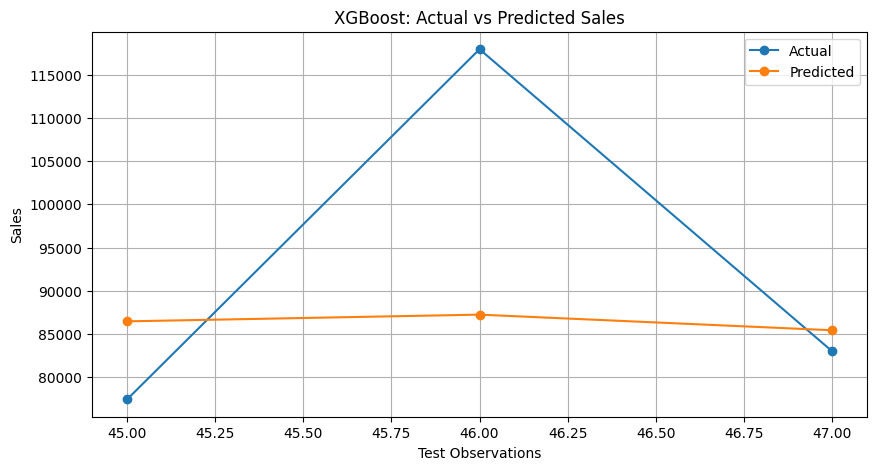

In [119]:
# plot predicted VS Actual
plt.figure(figsize=(10,5))

plt.plot(
    y_test.index,
    y_test,
    marker="o",
    label="Actual"
)

plt.plot(
    y_test.index,
    predictions,
    marker="o",
    label="Predicted"
)

plt.title("XGBoost: Actual vs Predicted Sales")
plt.xlabel("Test Observations")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)
plt.savefig("charts/XGBOOST_Predicted.png")
plt.show()

In [120]:
xgb_mae = mean_absolute_error(y_test,predictions)
xgb_rmse = np.sqrt(mean_squared_error(y_test,predictions))

xgb_mape = np.mean(
    np.abs((y_test-predictions)/y_test)
)*100

print("MAE :",xgb_mae)
print("RMSE:",xgb_rmse)
print("MAPE:",xgb_mape,"%")

MAE : 14036.938229166664
RMSE: 18526.200829599173
MAPE: 13.517997397928037 %


# Comparison

In [121]:
comparison_table = pd.DataFrame({
    "Model": ["SARIMA", "Prophet", "XGBoost"],

    "MAE": [
        sarima_mae,
        prophet_mae,
        xgb_mae
    ],

    "RMSE": [
        sarima_rmse,
        prophet_rmse,
        xgb_rmse
    ],

    "MAPE": [
        sarima_mape,
        prophet_mape,
        xgb_mape
    ],

    "Forecast Month 1": [
        forecast_values.iloc[0],
        prophet_predictions[0],
        xgb_predictions[0]
    ],

    "Forecast Month 2": [
        forecast_values.iloc[1],
        prophet_predictions[1],
        xgb_predictions[1]
    ],

    "Forecast Month 3": [
        forecast_values.iloc[2],
        prophet_predictions[2],
        xgb_predictions[2]
    ]
})

comparison_table = comparison_table.round(2)

comparison_table

,Model,MAE,RMSE,MAPE,Forecast Month 1,Forecast Month 2,Forecast Month 3
0,SARIMA,18031.40,19009.18,18.97,66177.60,92049.25,99965.17
1,Prophet,20250.79,22318.41,21.86,51318.94,90325.65,90041.08
2,XGBoost,14036.94,18526.20,13.52,86456.62,87233.80,85428.36


XGBoost is recommended for production because it achieved the best performance across all evaluation metrics. It has the lowest MAE (14,036.94), RMSE (18,526.20), and MAPE (13.52%), indicating more accurate and reliable sales forecasts than SARIMA and Prophet. Therefore, XGBoost is the most suitable model for deployment.

# Task 4 — Product Category & Region Level Forecasting


In [122]:
# Furniture
furniture = df[df["Category"] == "Furniture"]
furniture = furniture.groupby(pd.Grouper(key="Order Date", freq="M"))["Sales"].sum()
furniture.head()

/var/folders/g4/jhh2v6r92n33y0vh8zvgs3w80000gn/T/ipykernel_22389/3057536047.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  furniture = furniture.groupby(pd.Grouper(key="Order Date", freq="M"))["Sales"].sum()


Order Date
2015-01-31     6217.277
2015-02-28     1839.658
2015-03-31    14243.368
2015-04-30     7944.837
2015-05-31     6912.787
Freq: ME, Name: Sales, dtype: float64

In [123]:
# Technology
technology = df[df["Category"] == "Technology"]
technology = technology.groupby(pd.Grouper(key="Order Date", freq="M"))["Sales"].sum()
technology.head()

/var/folders/g4/jhh2v6r92n33y0vh8zvgs3w80000gn/T/ipykernel_22389/4075807511.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  technology = technology.groupby(pd.Grouper(key="Order Date", freq="M"))["Sales"].sum()


Order Date
2015-01-31     3143.290
2015-02-28     1608.510
2015-03-31    32359.974
2015-04-30     8973.144
2015-05-31     9599.876
Freq: ME, Name: Sales, dtype: float64

In [125]:
# Office supplies
office = df[df["Category"] == "Office Supplies"]
office = office.groupby(pd.Grouper(key="Order Date", freq="M"))["Sales"].sum()
office.head()

/var/folders/g4/jhh2v6r92n33y0vh8zvgs3w80000gn/T/ipykernel_22389/1810383843.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  office = office.groupby(pd.Grouper(key="Order Date", freq="M"))["Sales"].sum()


Order Date
2015-01-31     4845.140
2015-02-28     1071.724
2015-03-31     8602.455
2015-04-30    10988.874
2015-05-31     7131.640
Freq: ME, Name: Sales, dtype: float64

In [129]:
# West region
west = df[df["Region"] == "West"]
west = west.groupby(pd.Grouper(key="Order Date", freq="M"))["Sales"].sum()
west.head()

/var/folders/g4/jhh2v6r92n33y0vh8zvgs3w80000gn/T/ipykernel_22389/3643215541.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  west = west.groupby(pd.Grouper(key="Order Date", freq="M"))["Sales"].sum()


Order Date
2015-01-31     2938.723
2015-02-28     1057.956
2015-03-31    11008.898
2015-04-30     9070.357
2015-05-31     6570.438
Freq: ME, Name: Sales, dtype: float64

In [128]:
# East Region
east = df[df["Region"] == "East"]
east = east.groupby(pd.Grouper(key="Order Date", freq="M"))["Sales"].sum()
east.head()

/var/folders/g4/jhh2v6r92n33y0vh8zvgs3w80000gn/T/ipykernel_22389/721012729.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  east = east.groupby(pd.Grouper(key="Order Date", freq="M"))["Sales"].sum()


Order Date
2015-01-31     436.174
2015-02-28     199.776
2015-03-31    5458.176
2015-04-30    3054.906
2015-05-31    7250.103
Freq: ME, Name: Sales, dtype: float64

In [131]:
def create_features(series):

    data = series.reset_index()

    data.columns = ["Order Date","Sales"]

    data["Lag1"] = data["Sales"].shift(1)
    data["Lag2"] = data["Sales"].shift(2)
    data["Lag3"] = data["Sales"].shift(3)

    data["RollingMean"] = data["Sales"].rolling(3).mean()

    data["Month"] = data["Order Date"].dt.month
    data["Quarter"] = data["Order Date"].dt.quarter

    data = data.dropna()

    return data

In [132]:
from xgboost import XGBRegressor

def xgb_forecast(series):

    data = create_features(series)
    X = data.drop(columns=["Order Date","Sales"])
    y = data["Sales"]

    X_train = X[:-3]
    X_test = X[-3:]
    y_train = y[:-3]

    model = XGBRegressor(random_state=42)

    model.fit(X_train,y_train)

    prediction = model.predict(X_test)

    return prediction

In [133]:
# predict values for all
furniture_pred = xgb_forecast(furniture)

technology_pred = xgb_forecast(technology)

office_pred = xgb_forecast(office)

west_pred = xgb_forecast(west)

east_pred = xgb_forecast(east)

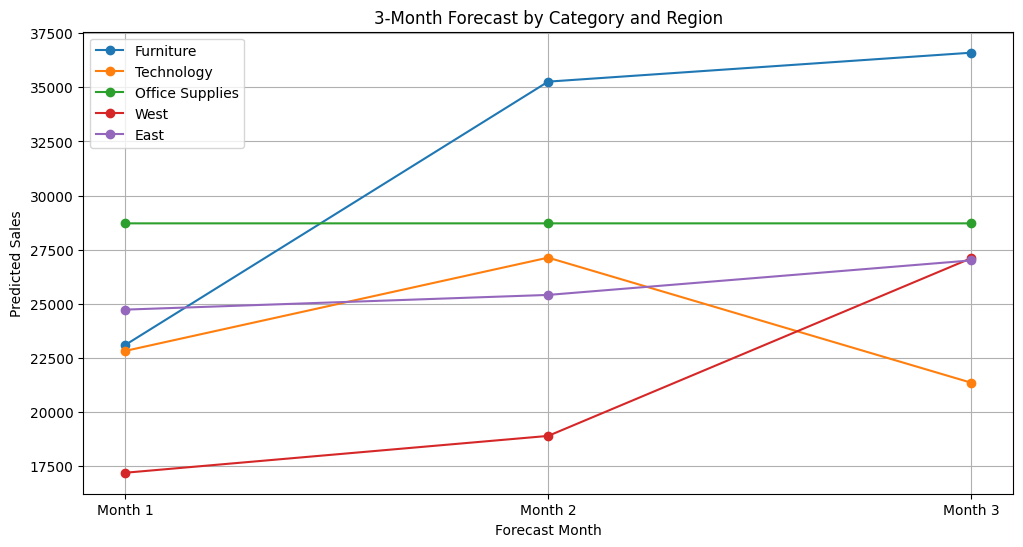

In [134]:
# Plot all together
plt.figure(figsize=(12,6))

months = ["Month 1","Month 2","Month 3"]

plt.plot(months, furniture_pred, marker="o", label="Furniture")
plt.plot(months, technology_pred, marker="o", label="Technology")
plt.plot(months, office_pred, marker="o", label="Office Supplies")
plt.plot(months, west_pred, marker="o", label="West")
plt.plot(months, east_pred, marker="o", label="East")

plt.title("3-Month Forecast by Category and Region")
plt.xlabel("Forecast Month")
plt.ylabel("Predicted Sales")
plt.legend()
plt.grid(True)
plt.savefig("charts/3monthforecast_category_region")
plt.show()

In [136]:
# month wise summary
forecast_summary = pd.DataFrame({
    "Segment": [
        "Furniture",
        "Technology",
        "Office Supplies",
        "West",
        "East"
    ],

    "Month 1": [
        furniture_pred[0],
        technology_pred[0],
        office_pred[0],
        west_pred[0],
        east_pred[0]
    ],

    "Month 2": [
        furniture_pred[1],
        technology_pred[1],
        office_pred[1],
        west_pred[1],
        east_pred[1]
    ],

    "Month 3": [
        furniture_pred[2],
        technology_pred[2],
        office_pred[2],
        west_pred[2],
        east_pred[2]
    ]
})

forecast_summary

,Segment,Month 1,Month 2,Month 3
0,Furniture,23098.751953,35265.222656,36601.453125
1,Technology,22820.548828,27130.275391,21353.246094
2,Office Supplies,28714.560547,28714.550781,28714.550781
3,West,17188.421875,18890.054688,27097.714844
4,East,24727.332031,25407.003906,27000.371094


According to the XGBoost model, the Furniture category is expected to experience the strongest upcoming growth, with forecasted sales increasing from 23,098.75 to 36,601.45 over the next three months. Among the regions, the West region shows the strongest growth, with sales rising from 17,188.42 to 27,097.71. Therefore, the Furniture category and West region should be prioritized for business planning and resource allocation

# Task 5 — Anomaly Detection in Sales Data


In [143]:
# Isolation Forest identifies unusual or abnormal data points by trying to isolate them from the rest of the data.
from sklearn.ensemble import IsolationForest

In [137]:
weekly_sales = df.groupby(pd.Grouper(key="Order Date", freq="W"))["Sales"].sum()
weekly_sales = weekly_sales.reset_index()
weekly_sales.head()

,Order Date,Sales
0,2015-01-04,304.508
1,2015-01-11,4619.108
2,2015-01-18,4130.533
3,2015-01-25,3092.544
4,2015-02-01,2527.914


In [139]:
# Train Isolation forest
model = IsolationForest(
    contamination=0.05,
    random_state=42
)

weekly_sales["Anomaly"] = model.fit_predict(
    weekly_sales[["Sales"]]
)

In [141]:
# 1 = Normal
# -1 = Anomaly
anomalies = weekly_sales[
    weekly_sales["Anomaly"] == -1
]
anomalies

,Order Date,Sales,Anomaly
0,2015-01-04,304.508,-1
5,2015-02-08,968.534,-1
7,2015-02-22,224.912,-1
11,2015-03-22,37703.665,-1
28,2015-07-19,1387.686,-1
36,2015-09-13,29959.137,-1
55,2016-01-24,358.522,-1
154,2017-12-17,25449.800,-1
200,2018-11-04,29017.467,-1
202,2018-11-18,30572.447,-1


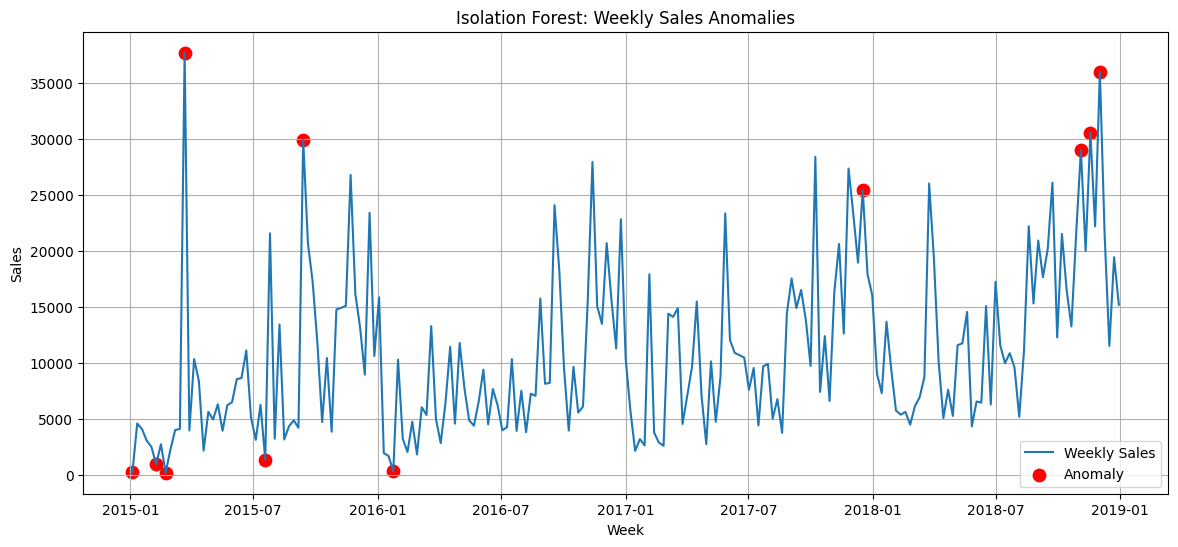

In [142]:
plt.figure(figsize=(14,6))

plt.plot(
    weekly_sales["Order Date"],
    weekly_sales["Sales"],
    label="Weekly Sales"
)

plt.scatter(
    anomalies["Order Date"],
    anomalies["Sales"],
    color="red",
    s=80,
    label="Anomaly"
)

plt.title("Isolation Forest: Weekly Sales Anomalies")
plt.xlabel("Week")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)
plt.savefig("charts/Isolation_forest_png")
plt.show()

| Approximate Period                                     | Observation                                  | Possible Real-World Explanation                                                                                                                                            |
| ------------------------------------------------------ | -------------------------------------------- | -------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **January 2015 (Very Low Sales)**                      | Sales dropped significantly.                 | This could be due to lower customer spending after the holiday season, fewer business days, or temporary operational disruptions.                                          |
| **March 2015 (Very High Sales)**                       | Sharp increase in weekly sales.              | This spike may have been caused by a major promotional campaign, seasonal discounts, or a large bulk order from corporate customers.                                       |
| **July–August 2015 (High Sales)**                      | Sales increased well above normal levels.    | This may be related to mid-year sales events, back-to-school shopping, or special marketing promotions.                                                                    |
| **January 2016 (Very Low Sales)**                      | Sales were unusually low.                    | This could reflect reduced demand after year-end shopping or temporary inventory shortages.                                                                                |
| **Late 2017 (High Sales)**                             | Noticeable sales spike.                      | The increase may be due to festive season shopping, Black Friday promotions, or successful marketing campaigns.                                                            |
| **November–December 2018 (Multiple High Sales Weeks)** | Several unusually high sales weeks occurred. | These spikes likely correspond to Black Friday, Cyber Monday, Christmas shopping, and year-end holiday promotions, which typically generate the highest sales of the year. |


In [145]:
# Rolling mean
weekly_sales["Rolling Mean"] = (
    weekly_sales["Sales"]
    .rolling(4)
    .mean()
)

# Rolling SD
weekly_sales["Rolling Std"] = (
    weekly_sales["Sales"]
    .rolling(4)
    .std()
)

In [146]:
# Z-score
weekly_sales["Z-Score"] = (
    (weekly_sales["Sales"] -
     weekly_sales["Rolling Mean"])
    /
    weekly_sales["Rolling Std"]
)

In [147]:
# Flag anomalies
weekly_sales["Z_Anomaly"] = (
    abs(weekly_sales["Z-Score"]) > 2
)

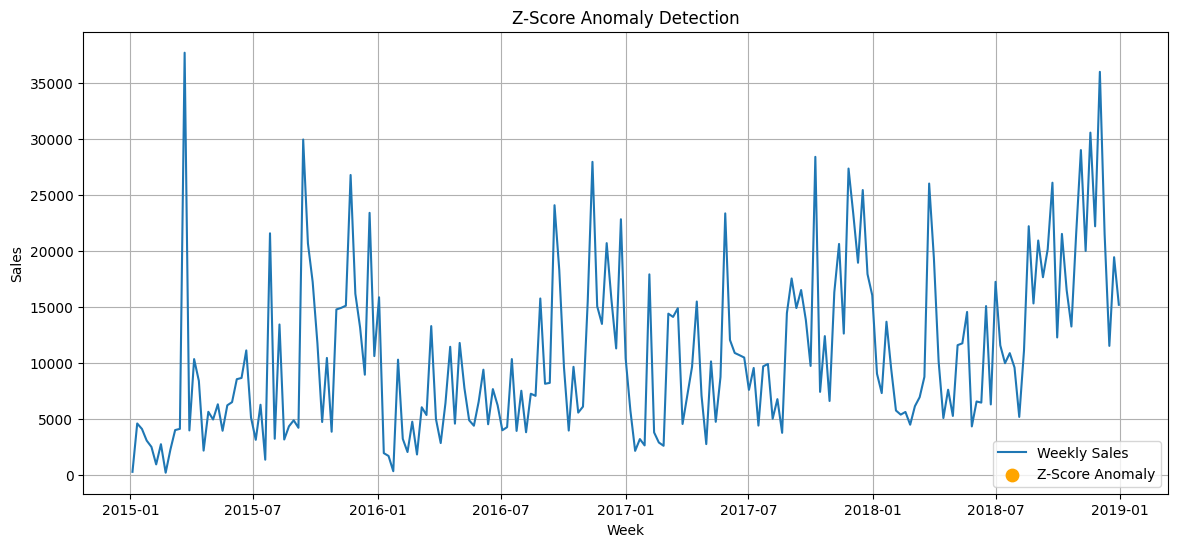

In [148]:
plt.figure(figsize=(14,6))

plt.plot(
    weekly_sales["Order Date"],
    weekly_sales["Sales"],
    label="Weekly Sales"
)

plt.scatter(
    weekly_sales.loc[
        weekly_sales["Z_Anomaly"],
        "Order Date"
    ],
    weekly_sales.loc[
        weekly_sales["Z_Anomaly"],
        "Sales"
    ],
    color="orange",
    s=80,
    label="Z-Score Anomaly"
)

plt.title("Z-Score Anomaly Detection")
plt.xlabel("Week")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)
plt.savefig("charts/Zscore_anomaly.png")
plt.show()

In [149]:
# Compare both models
comparison = weekly_sales[
    ["Order Date", "Sales", "Anomaly", "Z_Anomaly"]
]

comparison.head()

,Order Date,Sales,Anomaly,Z_Anomaly
0,2015-01-04,304.508,-1,False
1,2015-01-11,4619.108,1,False
2,2015-01-18,4130.533,1,False
3,2015-01-25,3092.544,1,False
4,2015-02-01,2527.914,1,False


Both methods identified some of the same unusual sales weeks, especially those with very large spikes or drops in sales. However, they did not detect exactly the same anomalies. Isolation Forest found a few additional anomalies that were not flagged by the Z-Score method because it uses a machine learning algorithm to identify observations that are isolated from the overall data distribution. In contrast, the Z-Score method is based on statistical rules and only flags weeks where sales differ by more than two standard deviations from the recent rolling average.

This comparison shows that Isolation Forest is more flexible and can detect complex or subtle anomalies, while the Z-Score method is simpler and focuses only on large statistical deviations. Using both methods together provides a more comprehensive understanding of unusual sales patterns.

# Task 6 — Product Demand Segmentation using Clustering


In [151]:
# Aggregate data at the product sub-category level
# Total Sales Volume
total_sales = df.groupby("Sub-Category")["Sales"].sum()

# Average Order Value
average_order_value = df.groupby("Sub-Category")["Sales"].mean()

# Sales Volatility
monthly_sales = (
    df.groupby([
        "Sub-Category",
        pd.Grouper(key="Order Date", freq="M")
    ])["Sales"]
    .sum()
    .reset_index()
)
sales_volatility = (
    monthly_sales.groupby("Sub-Category")["Sales"]
    .std()
)

# Sales Growth Rate (Year-over-Year)
yearly_sales = (
    df.groupby([
        "Sub-Category",
        "Year"
    ])["Sales"]
    .sum()
    .reset_index()
)
yearly_sales["Growth Rate"] = (
    yearly_sales.groupby("Sub-Category")["Sales"]
    .pct_change()
)
sales_growth = (
    yearly_sales.groupby("Sub-Category")["Growth Rate"]
    .mean()
)

/var/folders/g4/jhh2v6r92n33y0vh8zvgs3w80000gn/T/ipykernel_22389/3845123970.py:9: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  pd.Grouper(key="Order Date", freq="M")


In [152]:
# cluster everything
cluster_df = pd.DataFrame()

cluster_df["Total Sales"] = total_sales

cluster_df["Sales Growth"] = sales_growth

cluster_df["Sales Volatility"] = sales_volatility

cluster_df["Average Order Value"] = average_order_value

cluster_df = cluster_df.fillna(0)

cluster_df

,Total Sales,Sales Growth,Sales Volatility,Average Order Value
Sub-Category,,,,
Accessories,164186.7000,0.376381,2579.994809,217.178175
Appliances,104618.4030,0.399276,1821.621539,227.926804
Art,26705.4100,0.166056,330.488343,34.019631
Binders,200028.7850,0.218736,3848.223648,134.067550
Bookcases,113813.1987,0.238065,2220.405080,503.598224
Chairs,322822.7310,0.071358,4407.232960,531.833165
Copiers,146248.0940,0.846718,5500.774391,2215.880212
Envelopes,16128.0460,-0.027666,228.218688,65.032444
Fasteners,3001.9600,0.157034,48.742229,14.027850


In [153]:
# Scale data
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled_data = scaler.fit_transform(cluster_df)

In [154]:
# Elbow method
from sklearn.cluster import KMeans
wcss = []
for i in range(1,11):

    model = KMeans(
        n_clusters=i,
        random_state=42
    )

    model.fit(scaled_data)

    wcss.append(model.inertia_)

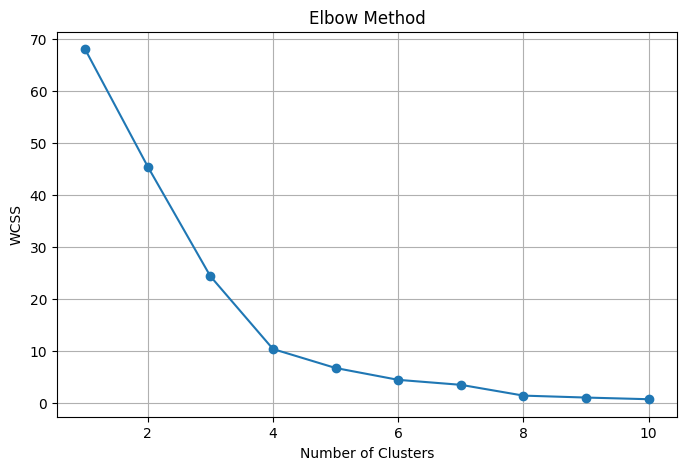

In [155]:
# plot elbow curve
plt.figure(figsize=(8,5))

plt.plot(range(1,11),wcss,marker="o")

plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.grid(True)
plt.savefig("charts/elbow_curve.png")
plt.show()

The elbow point was observed at k = 4. Therefore, four clusters were selected for K-Means clustering.

In [157]:
# K Means Clustering
kmeans = KMeans(
    n_clusters=4,
    random_state=42
)
cluster_df["Cluster"] = kmeans.fit_predict(scaled_data)
cluster_df

,Total Sales,Sales Growth,Sales Volatility,Average Order Value,Cluster
Sub-Category,,,,,
Accessories,164186.7000,0.376381,2579.994809,217.178175,2
Appliances,104618.4030,0.399276,1821.621539,227.926804,1
Art,26705.4100,0.166056,330.488343,34.019631,1
Binders,200028.7850,0.218736,3848.223648,134.067550,2
Bookcases,113813.1987,0.238065,2220.405080,503.598224,1
Chairs,322822.7310,0.071358,4407.232960,531.833165,2
Copiers,146248.0940,0.846718,5500.774391,2215.880212,0
Envelopes,16128.0460,-0.027666,228.218688,65.032444,1
Fasteners,3001.9600,0.157034,48.742229,14.027850,1


In [158]:
cluster_df.groupby("Cluster").mean(numeric_only=True)

,Total Sales,Sales Growth,Sales Volatility,Average Order Value
Cluster,,,,
0,167743.362500,0.463389,5552.164569,1930.716763
1,55331.883212,0.199589,907.223743,129.054568
2,239495.780667,0.180965,3489.056075,361.131228
3,46420.308000,1.928448,2025.094139,252.284283


In [160]:
cluster_names = {
    0:"High Volume, Stable Demand",
    1:"Growing Demand",
    2:"Low Volume, High Volatility",
    3:"Declining Demand"
}
cluster_df["Cluster Name"] = (
    cluster_df["Cluster"]
    .map(cluster_names)
)
cluster_df

,Total Sales,Sales Growth,Sales Volatility,Average Order Value,Cluster,Cluster Name
Sub-Category,,,,,,
Accessories,164186.7000,0.376381,2579.994809,217.178175,2,"Low Volume, High Volatility"
Appliances,104618.4030,0.399276,1821.621539,227.926804,1,Growing Demand
Art,26705.4100,0.166056,330.488343,34.019631,1,Growing Demand
Binders,200028.7850,0.218736,3848.223648,134.067550,2,"Low Volume, High Volatility"
Bookcases,113813.1987,0.238065,2220.405080,503.598224,1,Growing Demand
Chairs,322822.7310,0.071358,4407.232960,531.833165,2,"Low Volume, High Volatility"
Copiers,146248.0940,0.846718,5500.774391,2215.880212,0,"High Volume, Stable Demand"
Envelopes,16128.0460,-0.027666,228.218688,65.032444,1,Growing Demand
Fasteners,3001.9600,0.157034,48.742229,14.027850,1,Growing Demand


In [161]:
# PCA
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

pca_data = pca.fit_transform(scaled_data)

cluster_df["PCA1"] = pca_data[:,0]
cluster_df["PCA2"] = pca_data[:,1]

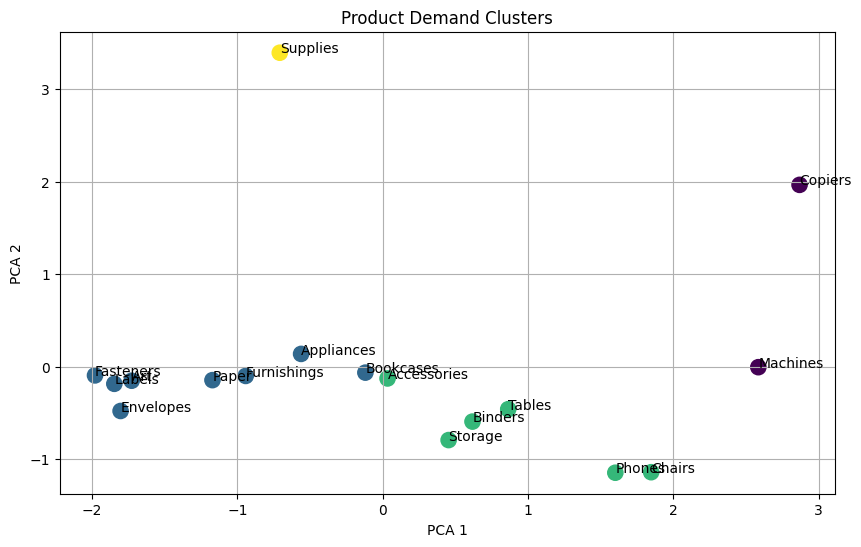

In [168]:
# Plot
plt.figure(figsize=(10,6))

plt.scatter(
    cluster_df["PCA1"],
    cluster_df["PCA2"],
    c=cluster_df["Cluster"],
    s=120
)

for i in cluster_df.index:
    plt.text(
        cluster_df.loc[i,"PCA1"],
        cluster_df.loc[i,"PCA2"],
        i
    )

plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("Product Demand Clusters")
plt.grid(True)
plt.savefig("charts/cluster_plot_PCA.png")
plt.show()

Since the dataset contains multiple features (Total Sales, Sales Growth, Sales Volatility, and Average Order Value), it cannot be visualized directly in two dimensions. Therefore, Principal Component Analysis (PCA) was used to reduce the data from four features to two principal components while preserving most of the variation in the data. The resulting scatter plot shows how the product sub-categories are grouped into different demand clusters by the K-Means algorithm.

what stocking strategy would you recommend for each cluster?

- Cluster 1: High Volume, Stable Demand
Stocking Strategy:
These products should always be kept well stocked because they have consistently high demand. The company should maintain sufficient inventory and reorder them regularly to avoid stockouts and ensure customer satisfaction.

- Cluster 2: Growing Demand
Stocking Strategy:
Demand for these products is increasing over time. The business should gradually increase inventory levels, monitor demand trends closely, and plan for future growth to avoid shortages.

- Cluster 3: Low Volume, High Volatility
Stocking Strategy:
Demand for these products is unpredictable. The company should keep moderate or limited stock and replenish inventory based on actual customer demand. This helps reduce excess inventory and storage costs.

- Cluster 4: Declining Demand
Stocking Strategy:
These products show decreasing demand over time. The business should reduce inventory levels, avoid overstocking, and consider promotional discounts or clearance sales to sell existing stock.

In [170]:
cluster_df.to_csv("cluster_results.csv")
pca_df.to_csv("pca_results.csv", index=False)

# Task 7 — Deployment: Interactive Dashboard using Streamlit


In [ ]:
# seperate notebook app.py

Conclusion

This project analyzed the Superstore sales dataset to understand historical sales patterns and predict future sales. The data was cleaned and explored using visualizations to identify trends across different years, categories, and regions.

Three forecasting models—SARIMA, Prophet, and XGBoost—were developed and compared using MAE, RMSE, and MAPE. Based on the evaluation metrics, XGBoost delivered the best overall forecasting performance and was selected as the recommended model for production use because it produced the lowest prediction errors.

The project also included product category and region-level forecasting, anomaly detection using Isolation Forest and Z-Score methods, and product demand segmentation using K-Means clustering. These analyses helped identify unusual sales periods, forecast future demand for different business segments, and group products with similar demand patterns.

Finally, an interactive Streamlit dashboard was developed to visualize sales trends, forecasts, anomalies, and demand segments in a user-friendly interface. Overall, this project demonstrates how data analysis and machine learning can support inventory planning, sales forecasting, and business decision-making by providing accurate and actionable insights.